In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Layer, Flatten, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras import Model
from tensorflow.keras import backend as K
from sklearn.impute import SimpleImputer

In [2]:
# Step 1: Load and preprocess the data
df = pd.read_csv('binary_classification_dataset.csv')  # Update with your dataset path

imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

X = df_imputed.iloc[:, :-1]  # All columns except the last
y = df_imputed.iloc[:, -1]    # The last column is the target

In [3]:
# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Step 3: Feature extraction using PCA (or other methods)
pca = PCA(n_components=0.95)  # Retain 95% variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [5]:
# Step 4: Feature selection using Gradient Boosting (after PCA)
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_pca, y_train)

feature_importances = gb_model.feature_importances_
importance_df = pd.DataFrame({'Feature': range(X_train_pca.shape[1]), 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

top_n = 10  # Adjust the number of top features to select
top_features = importance_df.head(top_n)['Feature'].values
X_train_selected = X_train_pca[:, top_features]
X_test_selected = X_test_pca[:, top_features]

In [6]:
# Step 5: Normalize the selected features
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_selected)
X_test_selected = scaler.transform(X_test_selected)

In [7]:
# Step 6: Fine-tune Gradient Boosting using GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}
grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_selected, y_train)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [8]:
# Step 7: Use the best Gradient Boosting model
best_gb_model = grid_search.best_estimator_

In [9]:
# Step 8: Define the Attention Layer class
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1), initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='att_bias', shape=(input_shape[1],), initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return output

In [10]:
# Step 9: Build the Neural Network with Attention
input_layer = Input(shape=(top_n,))
attention_layer = AttentionLayer()(input_layer)
flatten_layer = Flatten()(attention_layer)
dense_layer1 = Dense(64, activation='relu')(flatten_layer)
dense_layer2 = Dense(32, activation='relu')(dense_layer1)
output_layer = Dense(1, activation='sigmoid')(dense_layer2)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
# Step 10: Train the GBNN model
history = model.fit(X_train_selected, y_train, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30
230/230 [==============================] - 3s 7ms/step - loss: 0.3916 - accuracy: 0.8510 - val_loss: 0.2292 - val_accuracy: 0.9109
Epoch 2/30
230/230 [==============================] - 1s 5ms/step - loss: 0.1644 - accuracy: 0.9399 - val_loss: 0.1423 - val_accuracy: 0.9457
Epoch 3/30
230/230 [==============================] - 1s 5ms/step - loss: 0.1228 - accuracy: 0.9568 - val_loss: 0.1205 - val_accuracy: 0.9484
Epoch 4/30
230/230 [==============================] - 1s 6ms/step - loss: 0.1086 - accuracy: 0.9632 - val_loss: 0.1187 - val_accuracy: 0.9478
Epoch 5/30
230/230 [==============================] - 1s 5ms/step - loss: 0.1025 - accuracy: 0.9637 - val_loss: 0.1098 - val_accuracy: 0.9614
Epoch 6/30
230/230 [==============================] - 1s 5ms/step - loss: 0.0963 - accuracy: 0.9664 - val_loss: 0.1066 - val_accuracy: 0.9641
Epoch 7/30
230/230 [==============================] - 1s 4ms/step - loss: 0.0942 - accuracy: 0.9675 - val_loss: 0.1062 - val_accuracy: 0.9582
Epoch 

In [12]:
# Step 11: CNN-LSTM Hybrid Model
# Reshape input data for CNN [samples, time steps, features]
X_cnn_reshaped = np.reshape(X_train.values, (X_train.shape[0], X_train.shape[1], 1))

# Build CNN-LSTM hybrid model
cnn_lstm_model = Sequential()
cnn_lstm_model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_cnn_reshaped.shape[1], 1)))
cnn_lstm_model.add(MaxPooling1D(pool_size=2))
cnn_lstm_model.add(LSTM(50))
cnn_lstm_model.add(Dense(1, activation='sigmoid'))

cnn_lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn_lstm_model.fit(X_cnn_reshaped, y_train.values.reshape(-1, 1), epochs=100)

# Reshape test data similarly and predict
X_test_cnn_reshaped = np.reshape(X_test.values, (X_test.shape[0], X_test.shape[1], 1))
y_pred_cnn_lstm_prob = cnn_lstm_model.predict(X_test_cnn_reshaped)

Epoch 1/100
288/288 [==============================] - 19s 51ms/step - loss: 0.2066 - accuracy: 0.9163
Epoch 2/100
288/288 [==============================] - 17s 58ms/step - loss: 0.1274 - accuracy: 0.9528
Epoch 3/100
288/288 [==============================] - 18s 64ms/step - loss: 0.1264 - accuracy: 0.9543
Epoch 4/100
288/288 [==============================] - 19s 66ms/step - loss: 0.1179 - accuracy: 0.9560
Epoch 5/100
288/288 [==============================] - 17s 60ms/step - loss: 0.1007 - accuracy: 0.9624
Epoch 6/100
288/288 [==============================] - 17s 59ms/step - loss: 0.0982 - accuracy: 0.9600
Epoch 7/100
288/288 [==============================] - 17s 59ms/step - loss: 0.0912 - accuracy: 0.9645
Epoch 8/100
288/288 [==============================] - 17s 58ms/step - loss: 0.0878 - accuracy: 0.9674
Epoch 9/100
288/288 [==============================] - 18s 62ms/step - loss: 0.0842 - accuracy: 0.9659
Epoch 10/100
288/288 [==============================] - 17s 60ms/step - l

In [13]:
# Step 12: Combine the models' predictions (Weighted Average)
y_pred_gbnn_prob = model.predict(X_test_selected)

# Weighted average of both predictions
alpha = 0.5  # You can adjust this weight to prioritize either model
y_pred_combined_prob = (alpha * y_pred_gbnn_prob + (1 - alpha) * y_pred_cnn_lstm_prob)

# Convert probabilities to binary predictions
y_pred_combined = (y_pred_combined_prob > 0.5).astype(int).flatten()

72/72 [==============================] - 0s 2ms/step


In [14]:
# Step 13: Evaluate the combined model
accuracy = accuracy_score(y_test, y_pred_combined)
print(f'Combined Model Accuracy: {accuracy:.2f}')

Combined Model Accuracy: 0.99


In [15]:
# Step 14: Classification Report and Confusion Matrix
print("Classification Report:")
print(classification_report(y_test, y_pred_combined))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_combined))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      1835
         1.0       0.99      0.97      0.98       465

    accuracy                           0.99      2300
   macro avg       0.99      0.98      0.99      2300
weighted avg       0.99      0.99      0.99      2300

Confusion Matrix:
[[1829    6]
 [  15  450]]


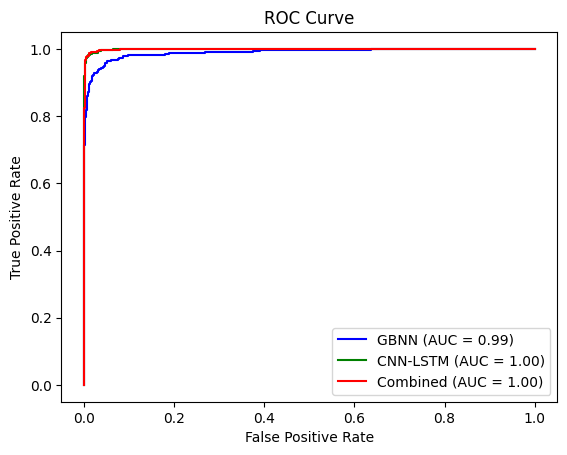

In [16]:
# Step 15: ROC Curve
fpr_gbnn, tpr_gbnn, _ = roc_curve(y_test, y_pred_gbnn_prob)
fpr_cnn_lstm, tpr_cnn_lstm, _ = roc_curve(y_test, y_pred_cnn_lstm_prob)
fpr_combined, tpr_combined, _ = roc_curve(y_test, y_pred_combined_prob)

roc_auc_gbnn = auc(fpr_gbnn, tpr_gbnn)
roc_auc_cnn_lstm = auc(fpr_cnn_lstm, tpr_cnn_lstm)
roc_auc_combined = auc(fpr_combined, tpr_combined)

plt.figure()
plt.plot(fpr_gbnn, tpr_gbnn, color='blue', label=f'GBNN (AUC = {roc_auc_gbnn:.2f})')
plt.plot(fpr_cnn_lstm, tpr_cnn_lstm, color='green', label=f'CNN-LSTM (AUC = {roc_auc_cnn_lstm:.2f})')
plt.plot(fpr_combined, tpr_combined, color='red', label=f'Combined (AUC = {roc_auc_combined:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


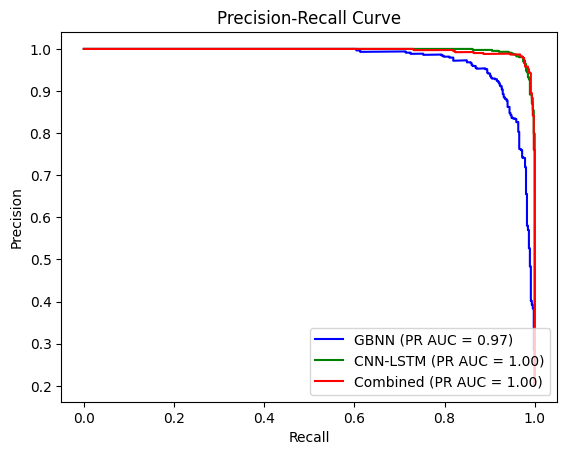

In [17]:
# Step 16: Precision-Recall Curve
precision_gbnn, recall_gbnn, _ = precision_recall_curve(y_test, y_pred_gbnn_prob)
precision_cnn_lstm, recall_cnn_lstm, _ = precision_recall_curve(y_test, y_pred_cnn_lstm_prob)
precision_combined, recall_combined, _ = precision_recall_curve(y_test, y_pred_combined_prob)

pr_auc_gbnn = auc(recall_gbnn, precision_gbnn)
pr_auc_cnn_lstm = auc(recall_cnn_lstm, precision_cnn_lstm)
pr_auc_combined = auc(recall_combined, precision_combined)
plt.figure()
plt.plot(recall_gbnn, precision_gbnn, color='blue', label=f'GBNN (PR AUC = {pr_auc_gbnn:.2f})')
plt.plot(recall_cnn_lstm, precision_cnn_lstm, color='green', label=f'CNN-LSTM (PR AUC = {pr_auc_cnn_lstm:.2f})')
plt.plot(recall_combined, precision_combined, color='red', label=f'Combined (PR AUC = {pr_auc_combined:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower right')
plt.show()
